# Variant calling benchmarks - All Chromosomes 
Used hap.py for benchmarking with rtg vcfeval engine
Strafication using GIAB v3.5

PacBio HiFi reads with DeepVariant calls used as truthset


In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
from pathlib import Path

run_names = {
    "aviti_ngi": "AVITI CB FS",
    "aviti_hq": "AVITI CB",
    "xplus_sns": "NovaSeqX+",
}

custom_params = {"axes.spines.right": False, "axes.spines.top": False, 'axes.edgecolor': 'black'}

sns.set_theme(style="ticks", rc=custom_params)
sns.set_context("notebook", font_scale=1.1)

basedir = Path("../analysis/variant_call_benchmarking_allchr")

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

## Filter Counts

In [2]:
data = pd.read_csv(basedir / "count_filters/aggregate_filters_mqc.txt", sep="\t", comment="#")
data["Data source"] = data["run"].replace(run_names)
data["Cell line"] = data["cell"]
data["Total"] = data["RefCall"] + data["PASS"]
data["pctRefCall"] = 100 * data["RefCall"] / data["Total"]
data

,run,cell,cov,PASS,RefCall,Data source,Cell line,Total,pctRefCall
0,aviti_hq,KMS12BM,10,4169071,858570,AVITI CB,KMS12BM,5027641,17.076995
1,aviti_hq,KMS12BM,15,4297807,1136544,AVITI CB,KMS12BM,5434351,20.914071
2,aviti_hq,KMS12BM,20,4332588,1259288,AVITI CB,KMS12BM,5591876,22.519956
3,aviti_hq,KMS12BM,25,4345154,1328261,AVITI CB,KMS12BM,5673415,23.412019
4,aviti_hq,KMS12BM,30,4351410,1370325,AVITI CB,KMS12BM,5721735,23.949466
...,...,...,...,...,...,...,...,...,...
57,xplus_sns,REH,15,5212714,3277303,NovaSeqX+,REH,8490017,38.601843
58,xplus_sns,REH,20,5252303,3116103,NovaSeqX+,REH,8368406,37.236518
59,xplus_sns,REH,25,5257125,2934226,NovaSeqX+,REH,8191351,35.821026
60,xplus_sns,REH,30,5253055,2789884,NovaSeqX+,REH,8042939,34.687370


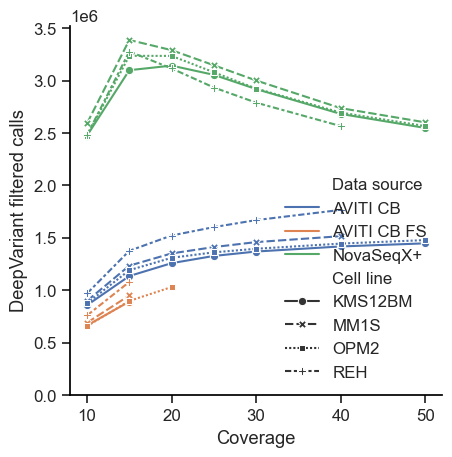

In [3]:
fig, ax = plt.subplots(figsize=(4.8, 4.8))
ax = sns.lineplot(data, x="cov", y="RefCall", hue="Data source", style="Cell line", markers=True)
ax.set_xlabel("Coverage")
ax.set_ylabel("DeepVariant filtered calls")
ax.set_ylim(bottom=0)
# Remove background on legend
ax.grid(False, axis="x")
ax.legend(frameon=False)



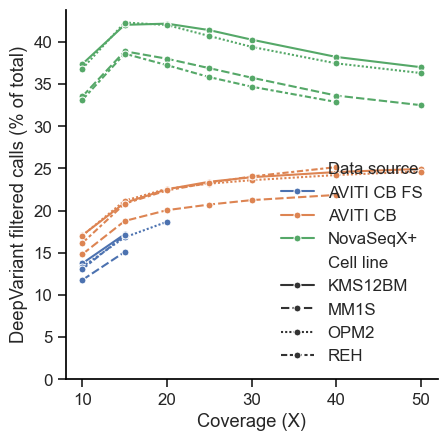

In [4]:
fig, ax = plt.subplots(figsize=(4.8, 4.8))
ax = sns.lineplot(data, x="cov", y="pctRefCall", hue="Data source", style="Cell line", marker="o",
                  markersize=5,
                  hue_order=run_names.values())
ax.set_xlabel("Coverage (X)")
ax.set_ylabel("DeepVariant filtered calls (% of total)")
ax.set_ylim(bottom=0)

# Remove background on legend
ax.grid(False, axis="x")
ax.legend(frameon=False)

plt.savefig(figdir / "variant_call_refcalls_allchr_pct.svg", backend='svg', 
            transparent=True, dpi=300, bbox_inches='tight')


## Summary data

In [5]:
# Load the summary data
sdata = []
for file in basedir.rglob("happy/*/*summary.csv"):
    df = pd.read_csv(file)
    run = file.parent.stem
    cell = file.stem.split("_")[0]
    cov = file.stem.split("_")[1]
    df["run"] = run
    df["Cell line"] = cell
    df["coverage"] = int(cov[:-1])
        
    sdata.append(df)

sdata = pd.concat(sdata).reset_index(drop=True)

# Only use PASS data
sdata = sdata.query("Filter == 'PASS'")# & coverage < 40")
sdata = sdata.drop("Filter", axis=1)
sdata["Data source"] = sdata["run"].replace(run_names)
sdata = sdata.sort_values(by="coverage")

sdata.head()

,Type,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,QUERY.UNK,FP.gt,FP.al,METRIC.Recall,...,METRIC.Frac_NA,METRIC.F1_Score,TRUTH.TOTAL.TiTv_ratio,QUERY.TOTAL.TiTv_ratio,TRUTH.TOTAL.het_hom_ratio,QUERY.TOTAL.het_hom_ratio,run,Cell line,coverage,Data source
149,INDEL,242137,212886,29251,789493,10352,566050,7397,1550,0.879196,...,0.716979,0.914920,NaN,NaN,1.297554,0.928218,xplus_sns,KMS12BM,10,NovaSeqX+
37,INDEL,242137,214705,27432,822298,9889,597535,6838,1770,0.886709,...,0.726665,0.920053,NaN,NaN,1.297554,0.872013,aviti_hq,KMS12BM,10,AVITI CB
43,SNP,2919500,2813949,105551,4399950,32839,1553181,18221,2429,0.963846,...,0.353000,0.976000,2.148371,2.008096,2.043256,1.512729,aviti_hq,MM1S,10,AVITI CB
91,SNP,2919500,2811590,107910,4400601,34307,1554719,19852,2390,0.963038,...,0.353297,0.975333,2.148371,2.005890,2.043256,1.518543,aviti_ngi,MM1S,10,AVITI CB FS
89,INDEL,351534,314971,36563,1039499,11757,712537,7438,2660,0.895990,...,0.685462,0.928771,NaN,NaN,2.340435,1.849311,aviti_ngi,MM1S,10,AVITI CB FS


### F1 Scores

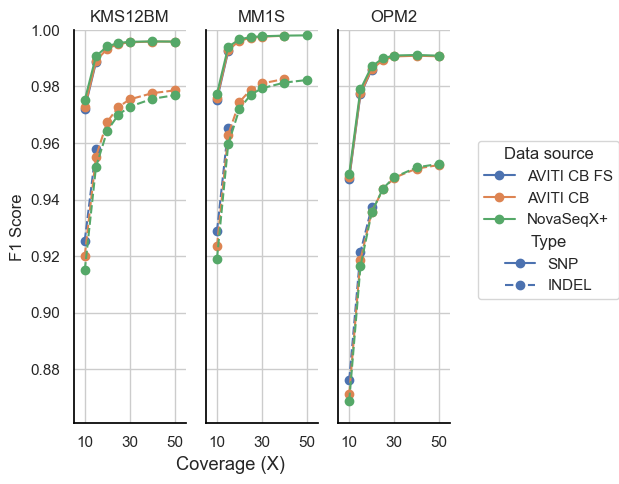

In [6]:
fig = plt.figure(figsize=(4.8, 4.8))
fig.text(0.5, 0.01, "Coverage (X)", ha='center', va='center')
p = (
    so.Plot(data=sdata, x="coverage", y="METRIC.F1_Score", color="Data source", linestyle="Type")
    .facet(col="Cell line")
    .add(so.Line(marker="o"))
    # Adjust aesthetics
    .scale(
        color=so.Nominal(order=list(run_names.values())),
        linestyle=so.Nominal(order=["SNP", "INDEL"]),
        x=so.Continuous().tick(at=[10, 30, 50])
    )
    .limit(y=(0.861, 1), x=(5, 55))
    .layout(size=(5, 4.8), engine="tight")
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .theme({'axes.edgecolor': 'black'})
    .label(
        x="",
        y="F1 Score",
    )
    .on(fig)
    .save(figdir / "variant_call_bench_f1_allchr_score_small.svg", backend='svg', 
          dpi=300, bbox_inches="tight", transparent=True)
    
)
#p.show()

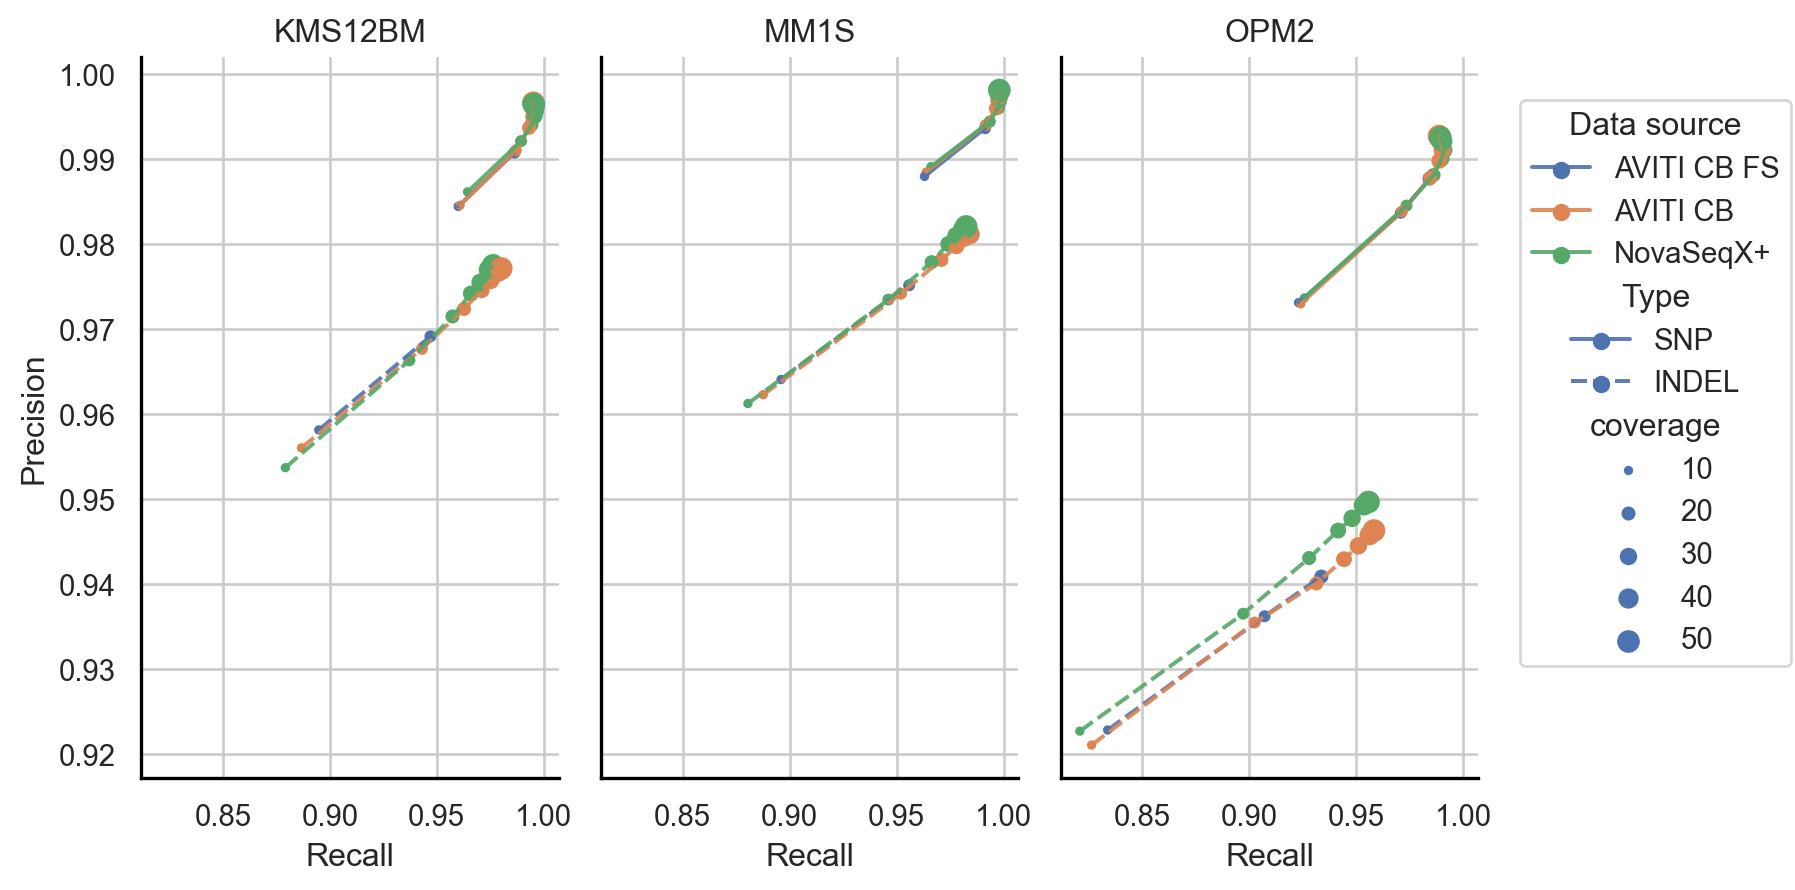

In [7]:

p = (
    so.Plot(data=sdata, x="METRIC.Recall", y="METRIC.Precision", color="Data source", linestyle="Type", )
    .facet(col="Cell line")
    .add(so.Path(alpha=0.9))
    .add(so.Dot(), pointsize="coverage")
    
    # Adjust aesthetics
    .scale(
        color=so.Nominal(order=list(run_names.values())),
        linestyle=so.Nominal(order=["SNP", "INDEL"]),
        pointsize=(3, 8)
    )
    #.limit(y=(0.861, 1), x=(5, 55))
    .layout(engine="tight", size=(8, 4.8))
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .theme({'axes.edgecolor': 'black'})
    .label(
        x="Recall",
        y="Precision",
    )

)
p

## Extended data

In [8]:
# Load the extended data
edata = []
for file in basedir.rglob("happy/*/*extended.csv"):
    print(file)
    df = pd.read_csv(file)
    run = file.parent.stem
    cell = file.stem.split("_")[0]
    cov = file.stem.split("_")[1]
    df["run"] = run
    df["Cell line"] = cell
    df["coverage"] = int(cov[:-1])
    edata.append(df)

edata = pd.concat(edata).reset_index(drop=True)

edata = edata[
    (edata["Filter"] == "PASS") &\
    (edata["Subtype"] == "*") &\
    ~(edata["Subset"].str.startswith("HG")) &\
    ~(edata["Subset"].str.startswith("ancestry")) &\
    ~(edata["Subset"].str.startswith("TS_"))
]
edata = edata.drop(["Filter", "Subtype"], axis=1)
edata["Data source"] = edata["run"].replace(run_names)

# Remove "SimpleRepeat" prefix to shorten stratification names
edata.loc[edata["Subset"].str.startswith("SimpleRepeat"),"Subset"] = edata[edata["Subset"].str.startswith("SimpleRepeat")]["Subset"].apply(lambda x: "_".join(x.split("_")[1:]))
edata.head()

../analysis/variant_call_benchmarking_allchr/happy/aviti_hq/MM1S_10X_vspacbio.extended.csv
../analysis/variant_call_benchmarking_allchr/happy/aviti_hq/KMS12BM_10X_vspacbio.extended.csv
../analysis/variant_call_benchmarking_allchr/happy/aviti_hq/KMS12BM_50X_vspacbio.extended.csv
../analysis/variant_call_benchmarking_allchr/happy/aviti_hq/KMS12BM_25X_vspacbio.extended.csv
../analysis/variant_call_benchmarking_allchr/happy/aviti_hq/OPM2_30X_vspacbio.extended.csv
../analysis/variant_call_benchmarking_allchr/happy/aviti_hq/MM1S_25X_vspacbio.extended.csv
../analysis/variant_call_benchmarking_allchr/happy/aviti_hq/KMS12BM_15X_vspacbio.extended.csv
../analysis/variant_call_benchmarking_allchr/happy/aviti_hq/MM1S_15X_vspacbio.extended.csv
../analysis/variant_call_benchmarking_allchr/happy/aviti_hq/MM1S_20X_vspacbio.extended.csv
../analysis/variant_call_benchmarking_allchr/happy/aviti_hq/KMS12BM_20X_vspacbio.extended.csv
../analysis/variant_call_benchmarking_allchr/happy/aviti_hq/OPM2_40X_vspacb

,Type,Subset,Genotype,QQ.Field,QQ,METRIC.Recall,METRIC.Precision,METRIC.Frac_NA,METRIC.F1_Score,FP.gt,...,QUERY.UNK.ti,QUERY.UNK.tv,QUERY.UNK.het,QUERY.UNK.homalt,QUERY.UNK.TiTv_ratio,QUERY.UNK.het_hom_ratio,run,Cell line,coverage,Data source
1,INDEL,*,*,DP,*,0.887689,0.962259,0.680630,0.923471,8028,...,.,.,421296.0,250591.0,NaN,1.681210,aviti_hq,MM1S,10,AVITI CB
3,INDEL,AllAutosomes,*,DP,*,0.887689,0.962259,0.667972,0.923471,8028,...,.,.,399710.0,234115.0,NaN,1.707323,aviti_hq,MM1S,10,AVITI CB
5,INDEL,AllHomopolymers_ge7bp_imperfectge11bp_slop5,*,DP,*,0.927324,0.977875,0.890093,0.951929,870,...,.,.,309599.0,164967.0,NaN,1.876733,aviti_hq,MM1S,10,AVITI CB
7,INDEL,AllTandemRepeats,*,DP,*,0.778534,0.914074,0.527655,0.840877,5908,...,.,.,71007.0,40552.0,NaN,1.751011,aviti_hq,MM1S,10,AVITI CB
9,INDEL,AllTandemRepeats_201to10000bp_slop5,*,DP,*,0.640970,0.901472,0.815722,0.749223,365,...,.,.,16150.0,11297.0,NaN,1.429583,aviti_hq,MM1S,10,AVITI CB


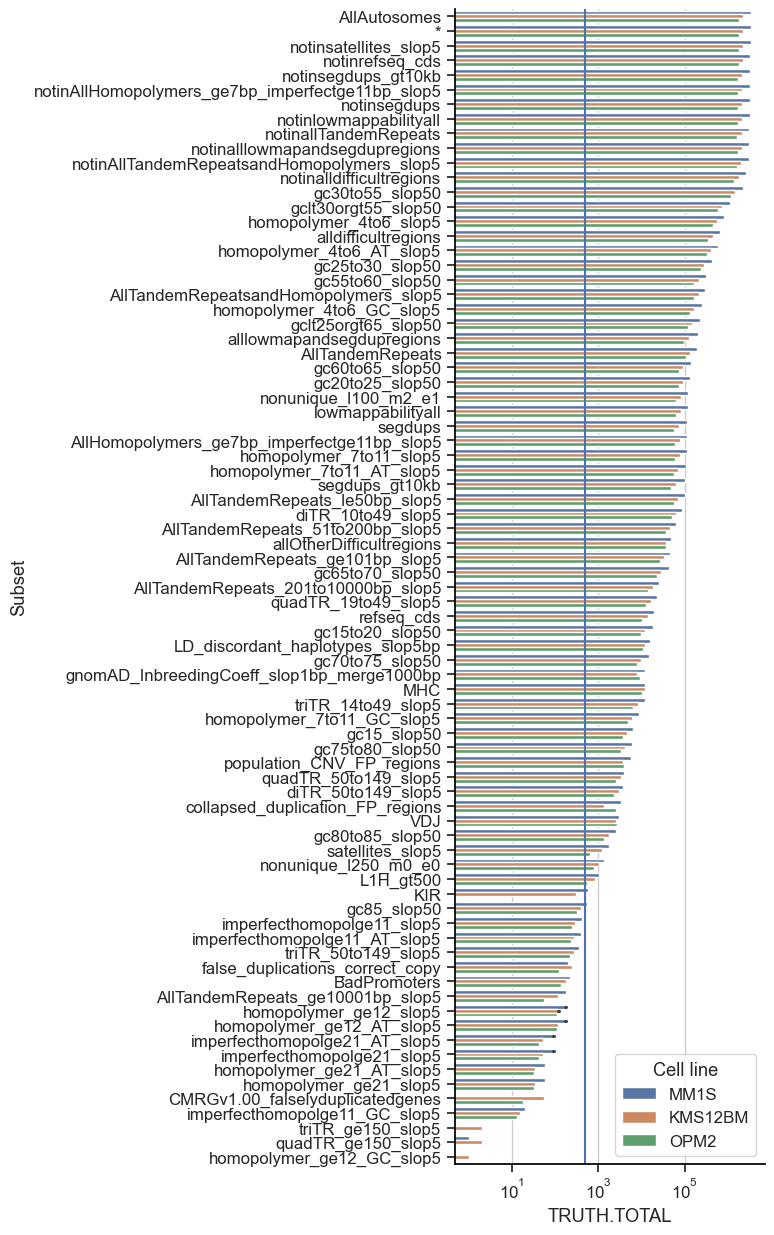

In [9]:
fig, ax = plt.subplots(figsize=(4, 15))
d = edata.groupby(["Subset", "Cell line", "Data source", "coverage"],as_index=False)\
    .agg({'TRUTH.TOTAL':"sum",'TRUTH.TP':"sum", 'TRUTH.FN':"sum",'QUERY.FP':"sum", "QUERY.TP": "sum", "Subset.Size": "first"})

d = d.sort_values(by="TRUTH.TOTAL", ascending=False)
d = d[d["TRUTH.TOTAL"] > 0]
ax = sns.barplot(d, x="TRUTH.TOTAL", y="Subset", orient="h", hue="Cell line", ax=ax)
ax.set_xscale("log")
ax.axvline(500)
ax.xaxis.grid(True)

### Top 10 split by +/-20X coverage

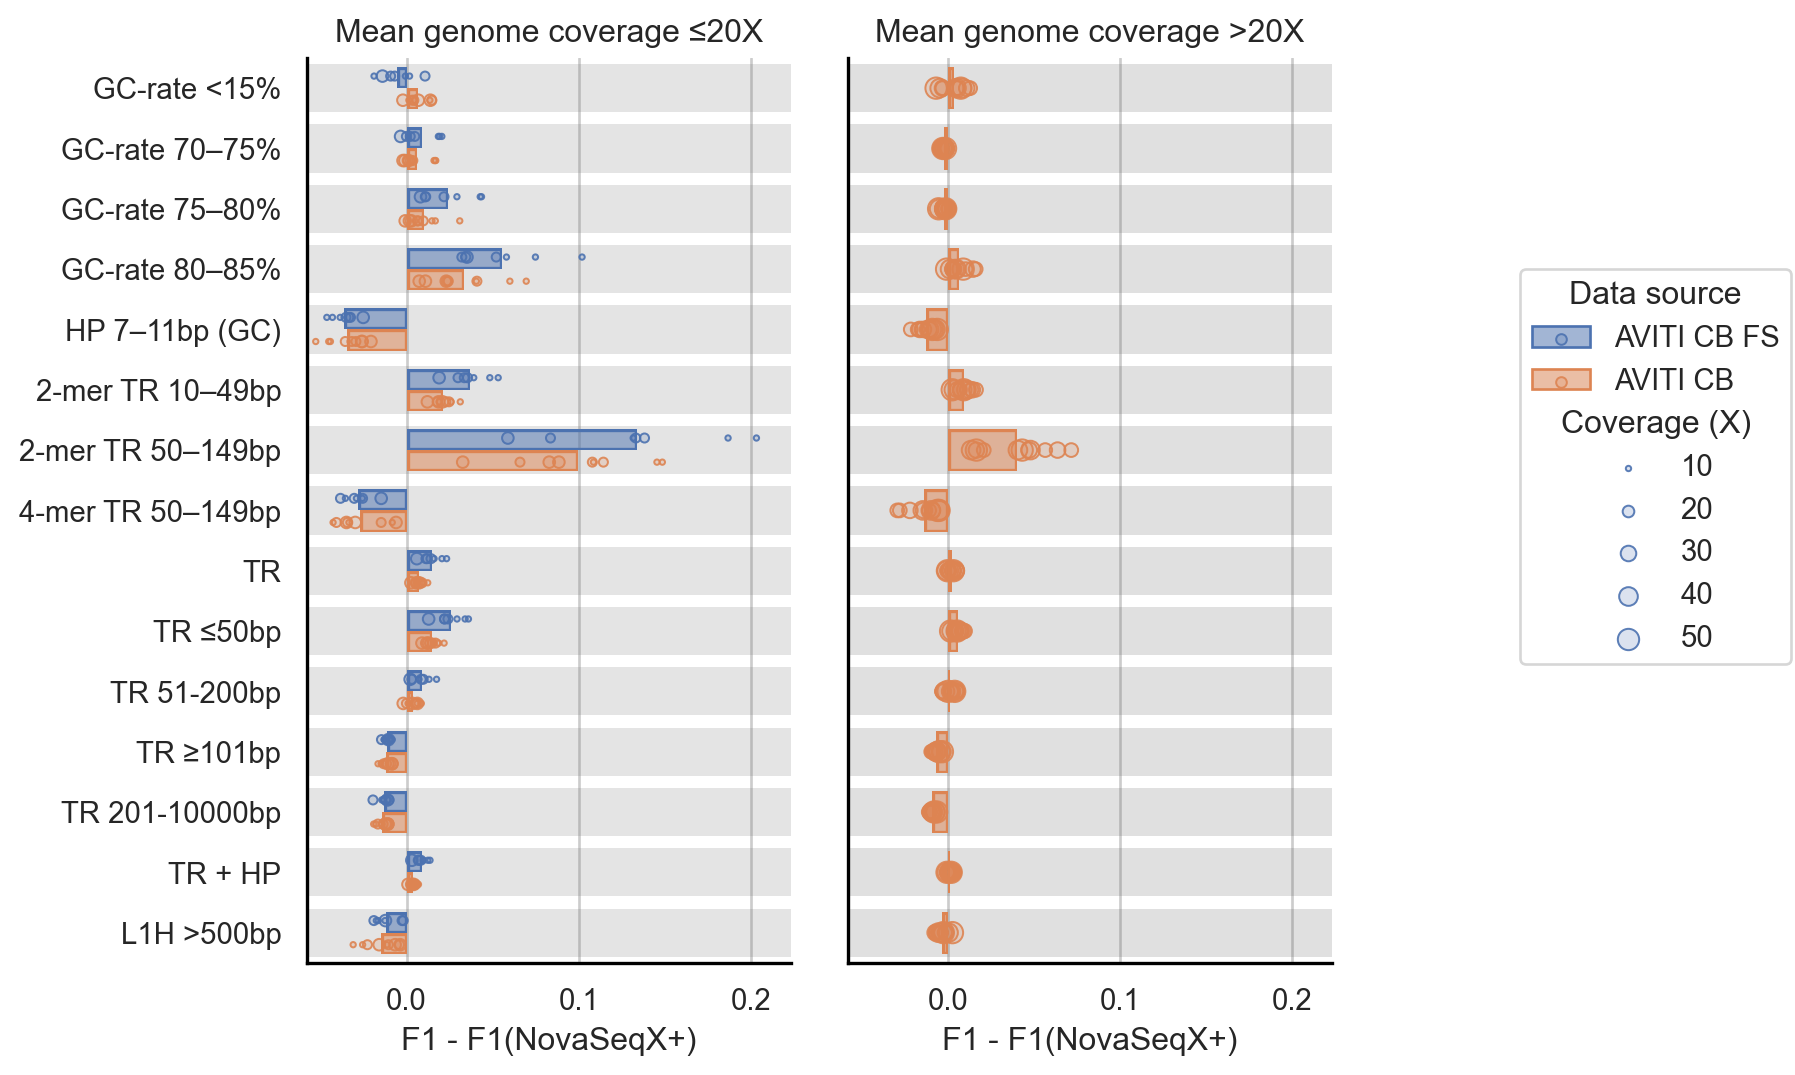

In [10]:
sns.set_style("whitegrid")
d = edata.copy()
d = d.groupby(["Subset", "Cell line", "Data source", "coverage"],as_index=False)\
    .agg({'TRUTH.TOTAL':"sum",'TRUTH.TP':"sum", 'TRUTH.FN':"sum",'QUERY.FP':"sum", "QUERY.TP": "sum", "Subset.Size": "first"})

d["F1"] = (d["TRUTH.TP"] + d["QUERY.TP"]) / (d["TRUTH.TP"] + d["QUERY.TP"] + d["QUERY.FP"] + d["TRUTH.FN"])

#Filter out subsets with few TRUTH Variant
subs_filt = d.groupby("Subset", as_index=False)["TRUTH.TOTAL"].min()\
    .query("`TRUTH.TOTAL` <= 500")["Subset"].unique()
d = d[~d["Subset"].isin(subs_filt)]

metric = "F1"

d = d.sort_values(by="Data source", ascending=False)
d[metric + "_gain"] = d.groupby(["Subset", "Cell line", "coverage"])[metric].transform(
    lambda x: (x-x.iloc[0])
)
d = d[d["Data source"] != "NovaSeqX+"]

# Mean absolute F1 difference
d["tmp"] = d.groupby(["Subset", "Data source"])["F1_gain"].transform(lambda x: x.abs().sum()/len(x))
d = d.sort_values(by="tmp", ascending=False)

# d["Subset"] = d["Subset"]\
#     .str.replace("imperfecthomopol", "Imperfect HP")\
#     .str.replace("homopolymer", "HP")\
#     .str.replace("Homopolymers", "HP")\
#     .str.replace("_", " ")\
#     .str.replace("ge", "≥")\
#     .str.replace("le", "≤")\
#     .str.replace("to", "–")\
#     .str.replace("gt", ">")\
#     .str.replace("slop50", "")\
#     .str.replace("slop5", "")\
#     .str.replace("gc", "GC-rate ")\
#     .str.replace("diTR", "2-mer TR")\
#     .str.replace("triTR", "3-mer TR")\
#     .str.replace("quadTR", "4-mer TR")\
#     .str.replace("AllTandemRepeats", "TR")\
#     .str.replace("and", "+")\

s_to_s = {
    'gc15_slop50': 'GC-rate <15%',
    'gc70to75_slop50': 'GC-rate 70–75%',
    'gc75to80_slop50': 'GC-rate 75–80%',
    'gc80to85_slop50': 'GC-rate 80–85%',
    'homopolymer_7to11_GC_slop5': 'HP 7–11bp (GC)',
    'diTR_10to49_slop5': '2-mer TR 10–49bp',
    'diTR_50to149_slop5': '2-mer TR 50–149bp',
    'quadTR_50to149_slop5': '4-mer TR 50–149bp',    
    'AllTandemRepeats': "TR",
    'AllTandemRepeats_le50bp_slop5': "TR ≤50bp",
    'AllTandemRepeats_51to200bp_slop5': "TR 51-200bp",
    'AllTandemRepeats_ge101bp_slop5': "TR ≥101bp",
    'AllTandemRepeats_201to10000bp_slop5': "TR 201-10000bp",
    'AllTandemRepeatsandHomopolymers_slop5': "TR + HP",
    "L1H_gt500": "L1H >500bp",
}
d["Subset"] = d["Subset"].replace(s_to_s)

strats = d.query("coverage <= 20")["Subset"].unique().tolist()[:15]
d = d[d["Subset"].isin(strats)]

d["Coverage_group"] = d["coverage"].apply(lambda x: "≤20X" if x <= 20 else ">20X")


hue_order=['AVITI CB FS', 'AVITI CB']
style_order = sorted(d["coverage"].unique())
d = d.rename(columns={"coverage": "Coverage (X)"})

bkg1 = d.query("`Data source` == 'AVITI CB'").copy() 
bkg1["F1_gain"] = d["F1_gain"].max() * 1.1

bkg2 = d.query("`Data source` == 'AVITI CB'").copy() 
bkg2["F1_gain"] = d["F1_gain"].min() * 1.1


p = (
    so.Plot(d, y="Subset", x="F1_gain", color="Data source", group="Data source", )
    .facet(col="Coverage_group")
    
    # Background bars
    .add(so.Bar(color="grey", alpha=0.02, edgewidth=0), data=bkg1)
    .add(so.Bar(color="grey", alpha=0.02, edgewidth=0), data=bkg2)

    # Plot cells
    .add(so.Bar(alpha=0.5, width=0.7), so.Agg("mean"), so.Dodge(by=["group"], gap=0, empty="fill"))
    .add(so.Dots(alpha=0.9), so.Dodge(by=["group"], gap=0, empty="fill"), pointsize="Coverage (X)") #marker="coverage")
    
    # Adjust aesthetics
    .scale(
        color=so.Nominal(order=hue_order),
        marker=so.Nominal(order=style_order),
        #y=so.Nominal(order=sorted(strats)),
        y=so.Nominal(order=list(s_to_s.values())),
        pointsize=(2, 8),
    )
    .limit(x=(d["F1_gain"].min()*1.1, d["F1_gain"].max()*1.1))
    .layout(size=(8, 1.2*4.8), engine="tight", extent=[0, 0, 0.9, 1])
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .theme({'axes.edgecolor': 'black'})
    .label(
        x="F1 - F1(NovaSeqX+)",
        y="",
        title="Mean genome coverage {}".format
    )
    .save(figdir / "variant_call_bench_f1_diff_allchr_stratification_small.svg", dpi=300, bbox_inches="tight", transparent=True)
)
p